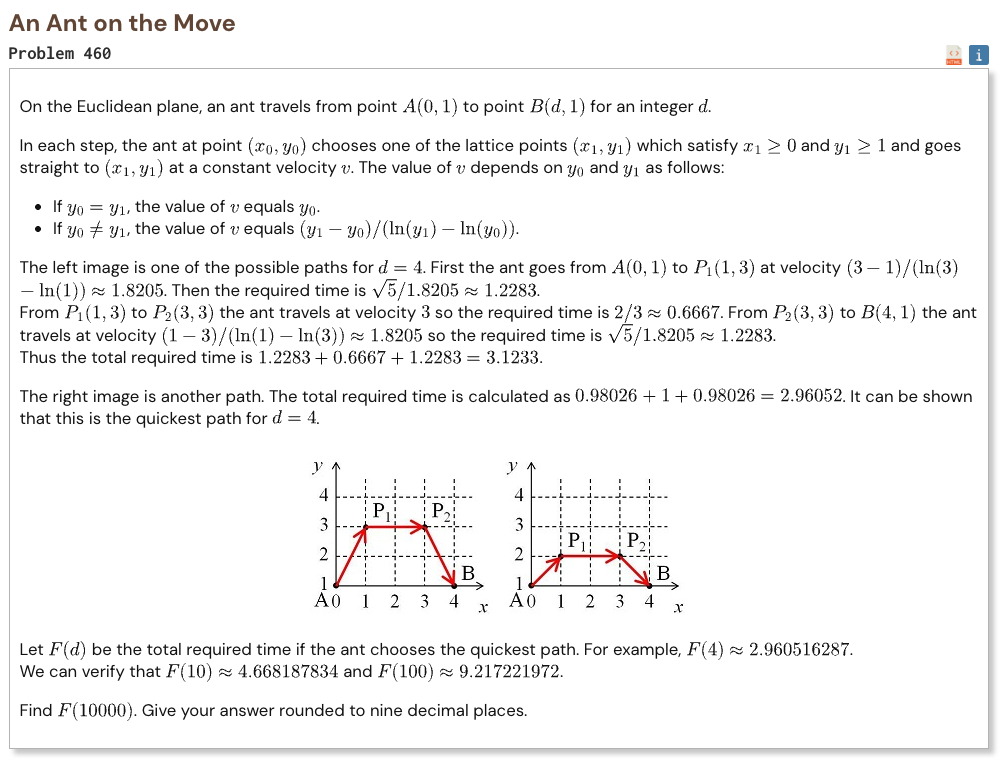

## Initial approach

-   the travel time of one straight segment is its Euclidean length divided by the logarithmic mean of the two heights
-   the continuous fastest path is close to a semicircle, so the useful lattice points are concentrated near that curve
-   solve only the first half of the path because the optimal route is symmetric around the midpoint
-   keep a small band of integer heights around the semicircle instead of considering every lattice point
-   also allow vertical moves at the same horizontal position because they are essential near the beginning of the path
-   use dynamic programming to store the fastest way to reach each candidate point
-   use numba to compile the large search loops because the full target is too slow in ordinary Python
-   double the best half path time and print the answer to nine decimal places

In [1]:
%%time

import math
import numpy as np
from numba import njit

D = 10_000
HALF = D // 2
BAND = 12
WINDOW = 700
START_HEIGHT = 800

MAX_CANDIDATES = max(2 * BAND + 1, START_HEIGHT)

@njit
def edge_time(x0, y0, x1, y1):
    dx = x1 - x0
    dy = y1 - y0

    if dy == 0:
        return abs(dx) / y0

    return (
        math.hypot(dx, dy)
        * math.log(y1 / y0)
        / dy
    )

@njit
def solve():
    heights = np.zeros(
        (HALF + 1, MAX_CANDIDATES),
        dtype=np.int32
    )

    counts = np.zeros(
        HALF + 1,
        dtype=np.int32
    )

    counts[0] = START_HEIGHT

    for y in range(1, START_HEIGHT + 1):
        heights[0, y - 1] = y

    for x in range(1, HALF + 1):
        centre = int(
            round(
                math.sqrt(
                    1.0 + D * x - x * x
                )
            )
        )

        index = 0

        for offset in range(-BAND, BAND + 1):
            y = centre + offset

            if y >= 1:
                heights[x, index] = y
                index += 1

        counts[x] = index

    inf = 1e100

    dp = np.full(
        (HALF + 1, MAX_CANDIDATES),
        inf,
        dtype=np.float64
    )

    for i in range(counts[0]):
        y = heights[0, i]

        if y == 1:
            dp[0, i] = 0.0
        else:
            dp[0, i] = math.log(y)

    for x in range(1, HALF + 1):
        start_x = max(0, x - WINDOW)

        for i in range(counts[x]):
            y = heights[x, i]
            best = inf

            for px in range(start_x, x):
                for j in range(counts[px]):
                    py = heights[px, j]

                    if py > y:
                        continue

                    candidate = (
                        dp[px, j]
                        + edge_time(px, py, x, y)
                    )

                    if candidate < best:
                        best = candidate

            for j in range(i):
                py = heights[x, j]

                if py < y:
                    candidate = (
                        dp[x, j]
                        + math.log(y / py)
                    )

                    if candidate < best:
                        best = candidate

            dp[x, i] = best

    best = inf

    for i in range(counts[HALF]):
        if dp[HALF, i] < best:
            best = dp[HALF, i]

    return 2.0 * best

result = solve()

print("Result:", f"{result:.9f}")

Result: 18.420738199
CPU times: user 13.7 s, sys: 148 ms, total: 13.9 s
Wall time: 14.4 s
